<a href="https://colab.research.google.com/github/AxisAngeles/Smart_Data_DS_AI/blob/main/Ejercicios_para_examen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creando un DataFrame de práctica con Numpy

# Preguntas

0.  **Data Generation**: Create a Pandas DataFrame named `df_exam` with fictional data including columns for 'City', 'Country', 'Region', 'Population', and 'Surface Area'.
1.  **Question 1 (Basic Exploration and Filtering)**:
    *   Display the first 5 rows of `df_exam`.
    *   Filter and display cities located in 'South America' with a 'Population' greater than 10,000,000.
2.  **Question 2 (New Column Creation and Sorting)**:
    *   Calculate a new column 'Population_Density' (Population / Surface Area) and add it to `df_exam`.
    *   Sort `df_exam` by 'Population_Density' in descending order and display the result.
3.  **Question 3 (Grouping and Aggregation)**:
    *   Group `df_exam` by 'Region' and calculate the total 'Population' for each region.
    *   Group `df_exam` by 'Country' and find the average 'Surface Area' for each country.
4.  **Question 4 (Row/Column Manipulation and Update)**:
    *   Remove the 'Population_Density' column from `df_exam`.
    *   Add a new city 'Lima', 'Peru', 'South America', with a population of 10,500,000 and a surface area of 3500 to `df_exam`.
    *   Update the 'Population' of 'Mexico City' to 22,000,000 in `df_exam`.
5.  **Question 5 (Data Visualization)**:
    *   Create a bar chart showing the 'Population' of the top 5 cities (by population).
    *   Create a pie chart showing the 'Surface Area' distribution by 'Country'.

Provide the Python code solutions for each question.

## Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from statistics import NormalDist

np.random.seed(2824)

In [ ]:
# 1) Elegir número de muestras
# n = int(input('Tamaño de la muestra: '))
n = 5

# 2) Crear columnas con valores aleatorios con Numpy

# 2.1) np.random.choice()     Selecciona entre una lista de variables con base en probabilidades dadas
cities = np.random.choice(['CDMX','GDL','MTY','NY','TX'], size=n, p=[0.40, 0.25, 0.05, 0.20, 0.10])

# 2.2) np.random.randint()    Crea valores enteros entre un rango dado
poblacion = np.random.randint(5000000,20000000,n)

# 2.3) np.random.randint()    Crea valores aleatorios con base en logaritmos normales.
superficie = np.random.lognormal(mean=1.0, sigma=0.45, size=n)
superficie = np.clip(superficie, 1, 5.5) # limita valores a un valor mínimo y uno máximo.

# 2.4) Otras opciones para números aleatorios
beta = superficie * np.random.beta(a=2.0, b=6.0, size=n)
pois = np.random.poisson(lam=1.2, size=n)


# 3) Transforma los arrays en DataFrame
df_exam = pd.DataFrame({
    'City': cities,
    'Population': poblacion,
    'Surface Area': superficie,
    'Beta': beta,
    'Pois': pois
})


# 4) Crear funciones para agrupar países y regiones con base en la ciudad

def selectpais(ciudad):
  if ciudad in ['CDMX','GDL','MTY']:
    return 'MX'
  elif ciudad in ['NY','TX']:
    return 'EU'
  else:
    return 'NA'

def selectregion(ciudad):
  if ciudad in ['CDMX']:
    return 'Centro'
  elif ciudad in ['GDL','MTY']:
    return 'Int_MX'
  elif ciudad in ['NY','TX']:
    return 'Norte'
  else:
    return 'NA'


# 5) Crear columnas con base en las funciones anteriores

df_exam['Country'] = df_exam.apply(lambda x: selectpais(x['City']), axis=1)
df_exam['Region'] = df_exam.apply(lambda x: selectregion(x['City']), axis=1)

# 6) Seleccionar columnas específcias
df_exam = df_exam[['City','Region','Country','Population','Surface Area']]
# df_exam.head()



# 7) ALTERNATIVA: Crear un Dataframe directamente
df_exam = pd.DataFrame(
    {
        'City': ['CDMX','GDL','MTY','NY','TX','Lima','Rio','Buenos Aires','Pekin'],
        'Region': ['MX_Centro','MX_Pacifico','MX_Norte','N_America','N_America','South America','South America','South America','Asia'],
        'Country': ['Mexico','Mexico','Mexico','EEUU','EEUU','Peru','Brasil','Argentina','China'],
        'Population': np.random.randint(5000000,20000000,9),
        'Surface Area(km2)': np.random.lognormal(mean=1.0, sigma=0.45, size=9),
    }
)

# 8) Cambiar el tipo de variable a "texto"
df_exam['City'] = df_exam['City'].astype('string')
df_exam['Region'] = df_exam['Region'].astype('string')
df_exam['Country'] = df_exam['Country'].astype('string')

df_exam

,City,Region,Country,Population,Surface Area(km2)
0,CDMX,MX_Centro,Mexico,10976383,2.673157
1,GDL,MX_Pacifico,Mexico,13308338,1.827121
2,MTY,MX_Norte,Mexico,5995376,3.956906
3,NY,N_America,EEUU,5486393,3.343211
4,TX,N_America,EEUU,8721195,1.807409
5,Lima,South America,Peru,10375829,2.432453
6,Rio,South America,Brasil,10686500,1.961266
7,Buenos Aires,South America,Argentina,8563546,2.936078
8,Pekin,Asia,China,7906588,2.559128


In [ ]:
# 1) Preguntas de Examen:

print("Display the first 5 rows of df_exam.")
display(df_exam.head())

print("\n\nFilter and display cities located in 'South America' with a 'Population' greater than 10,000,000.")
display(df_exam.loc[(df_exam['Region'] == 'South America') & (df_exam['Population'] >= 10000000)])

print("\n\nCalculate a new column 'Population_Density' (Population / Surface Area) and add it to df_exam.")
df_exam['Population_Density'] = np.round((df_exam['Population']/df_exam['Surface Area(km2)']),2)
display(df_exam['Population_Density'])

print("\n\nSort df_exam by 'Population_Density' in descending order and display the result.")
display(df_exam.sort_values(['Population_Density'], ascending=False))


print("\n\nGroup df_exam by 'Region' and calculate the total 'Population' for each region.")
display(df_exam[['Region','Population']].groupby('Region').sum().sort_values(['Population'], ascending=False))

print("\n\nGroup df_exam by 'Country' and find the average 'Surface Area' for each country.")
display(df_exam[['Country','Surface Area(km2)']].groupby('Country').agg(['count','mean','sum']))

print("\n\nRemove the 'Population_Density' column from df_exam.")
df_exam = df_exam.drop('Population_Density', axis=1)
display(df_exam)

print("\n\nAdd a new city 'Lima', 'Peru', 'South America', with a population of 10,500,000 and a surface area of 3500 to df_exam.")
df_exam.loc[9] = ['Lima2', 'South America', 'Peru', 10500000,3.500]
display(df_exam)

print("\n\nUpdate the 'Population' of 'Mexico City' to 22,000,000 in df_exam.")
var = df_exam.loc[df_exam['City'] == 'CDMX'].index
df_exam.at[0,'Population'] = 22000000
df_exam.loc[var[0]]


Display the first 5 rows of df_exam.


,City,Region,Country,Population,Surface Area(km2)
0,CDMX,MX_Centro,Mexico,10976383,2.673157
1,GDL,MX_Pacifico,Mexico,13308338,1.827121
2,MTY,MX_Norte,Mexico,5995376,3.956906
3,NY,N_America,EEUU,5486393,3.343211
4,TX,N_America,EEUU,8721195,1.807409




Filter and display cities located in 'South America' with a 'Population' greater than 10,000,000.


,City,Region,Country,Population,Surface Area(km2)
5,Lima,South America,Peru,10375829,2.432453
6,Rio,South America,Brasil,10686500,1.961266




Calculate a new column 'Population_Density' (Population / Surface Area) and add it to df_exam.


...

,City,Region,Country,Population,Surface Area(km2)
0,CDMX,MX_Centro,Mexico,10976383,2.673157
1,GDL,MX_Pacifico,Mexico,13308338,1.827121
2,MTY,MX_Norte,Mexico,5995376,3.956906
3,NY,N_America,EEUU,5486393,3.343211
4,TX,N_America,EEUU,8721195,1.807409
5,Lima,South America,Peru,10375829,2.432453
6,Rio,South America,Brasil,10686500,1.961266
7,Buenos Aires,South America,Argentina,8563546,2.936078
8,Pekin,Asia,China,7906588,2.559128




Add a new city 'Lima', 'Peru', 'South America', with a population of 10,500,000 and a surface area of 3500 to df_exam.


,City,Region,Country,Population,Surface Area(km2)
0,CDMX,MX_Centro,Mexico,10976383,2.673157
1,GDL,MX_Pacifico,Mexico,13308338,1.827121
2,MTY,MX_Norte,Mexico,5995376,3.956906
3,NY,N_America,EEUU,5486393,3.343211
4,TX,N_America,EEUU,8721195,1.807409
5,Lima,South America,Peru,10375829,2.432453
6,Rio,South America,Brasil,10686500,1.961266
7,Buenos Aires,South America,Argentina,8563546,2.936078
8,Pekin,Asia,China,7906588,2.559128
9,Lima2,South America,Peru,10500000,3.500000




Update the 'Population' of 'Mexico City' to 22,000,000 in df_exam.


,0
City,CDMX
Region,MX_Centro
Country,Mexico
Population,22000000
Surface Area(km2),2.673157


# Gráficas
5. Question 5 (Data Visualization):
* Create a bar chart showing the 'Population' of the top 5 cities (by population).
* Create a pie chart showing the 'Surface Area' distribution by 'Country'.

In [ ]:
df_exam

,City,Region,Country,Population,Surface Area(km2)
0,CDMX,MX_Centro,Mexico,22000000,2.673157
1,GDL,MX_Pacifico,Mexico,13308338,1.827121
2,MTY,MX_Norte,Mexico,5995376,3.956906
3,NY,N_America,EEUU,5486393,3.343211
4,TX,N_America,EEUU,8721195,1.807409
5,Lima,South America,Peru,10375829,2.432453
6,Rio,South America,Brasil,10686500,1.961266
7,Buenos Aires,South America,Argentina,8563546,2.936078
8,Pekin,Asia,China,7906588,2.559128
9,Lima2,South America,Peru,10500000,3.500000


### Matplotlib (BAR)

Create a bar chart showing the 'Population' of the top 5 cities (by population).



/tmp/ipykernel_452/1052059851.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7334619.6' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_plot.loc[len(df_plot)] = ['Others(avg)',df_exam[['Population']].sort_values('Population', ascending = True).head(5).mean()['Population']]


[Text(0, 0, '22.00'),
 Text(0, 0, '13.31'),
 Text(0, 0, '10.69'),
 Text(0, 0, '10.50'),
 Text(0, 0, '7.33')]

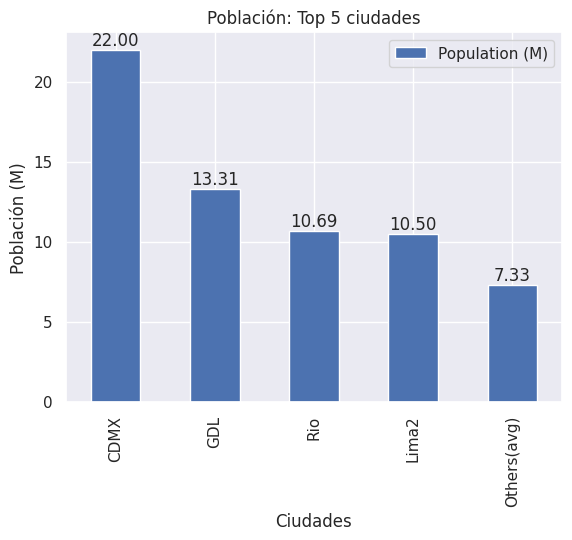

In [ ]:
import matplotlib.pyplot as plt #visualización de datos
import seaborn as sns #visualización de datos

%matplotlib inline
sns.set(style='darkgrid')


print("Create a bar chart showing the 'Population' of the top 5 cities (by population).\n")
df_plot = df_exam[['City','Population']].sort_values('Population', ascending = False).head(5)
df_plot.loc[len(df_plot)] = ['Others(avg)',df_exam[['Population']].sort_values('Population', ascending = True).head(5).mean()['Population']]
df_plot['Population (M)'] = round(df_plot['Population']/1000000,2)
df_plot = df_plot.drop('Population', axis = 1).set_index('City')

ax = df_plot.plot(kind = 'bar') #, title = ' ', ylabel=''

# Add axis labels and a title
ax.set_xlabel("Ciudades")
ax.set_ylabel("Población (M)")
ax.set_title("Población: Top 5 ciudades")
ax.bar_label(ax.containers[0], fmt='%.2f')


### Matplotlib (PIE)

Create a pie chart showing the 'Surface Area' distribution by 'Country'.


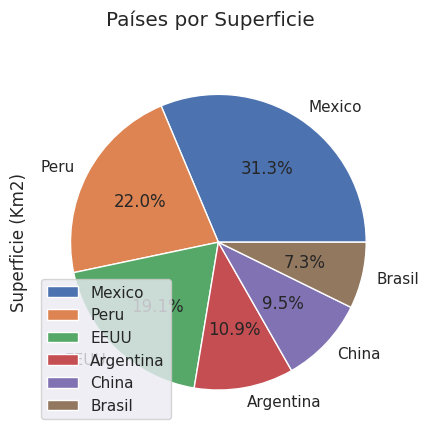

In [ ]:
print("Create a pie chart showing the 'Surface Area' distribution by 'Country'.")
df_plot = df_exam[['Surface Area(km2)','Country']].set_index('Country').groupby('Country').sum().sort_values('Surface Area(km2)', ascending = False)

ax = df_plot.plot(kind = 'pie', subplots=True,
                  title="Países por Superficie",
                  ylabel="Superficie (Km2)",
                  autopct='%1.1f%%') # Added autopct to display values


### Matplotlib (HIST)

array([[<Axes: title={'center': 'Surface Area(km2)'}>,
        <Axes: title={'center': 'Population'}>]], dtype=object)

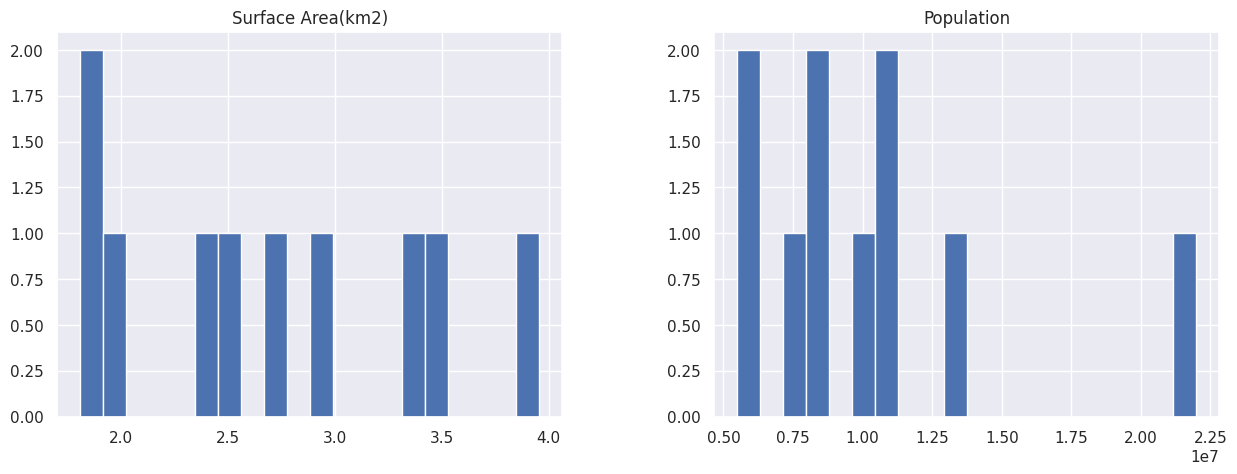

In [ ]:
df_exam[['Surface Area(km2)','Population']].hist(bins = 20, figsize=(15,5))

### Matplotlib (BoxPlot)

,0
Population,"Axes(0.125,0.11;0.775x0.77)"


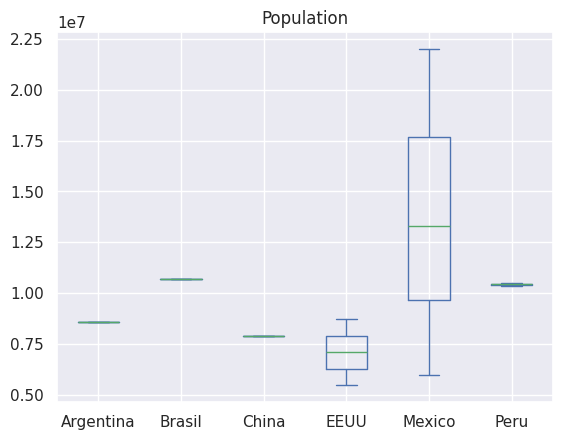

In [ ]:
df_exam[['Country','Population']].plot.box('Country')

### Matplotlib (Scatter)

<Axes: xlabel='Population', ylabel='Surface Area(km2)'>

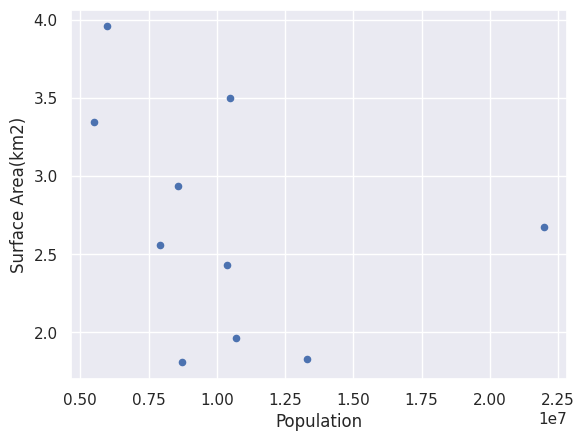

In [ ]:
df_exam.plot.scatter(x = 'Population', y='Surface Area(km2)')

### Seaborn (Pairplot)

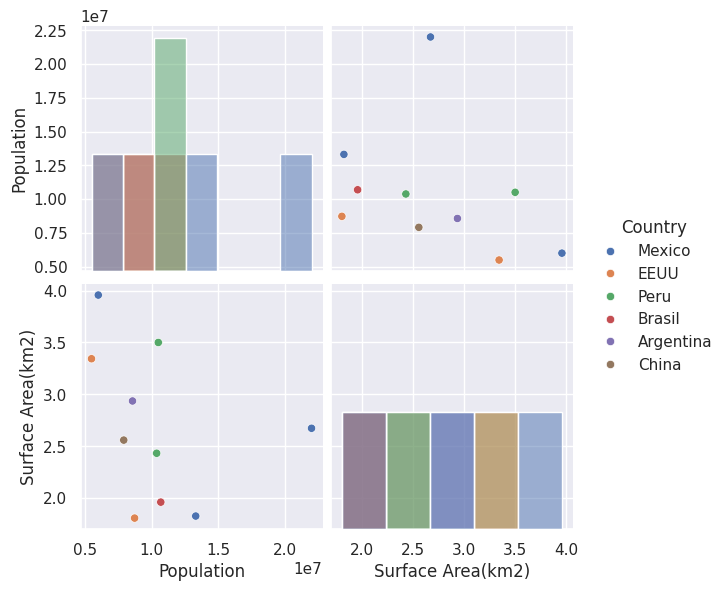

In [ ]:
sns.pairplot(df_exam[['Population','Surface Area(km2)','Country']], height=3, diag_kind = 'hist', hue='Country',)

### Seaborn (Corr)

<Axes: >

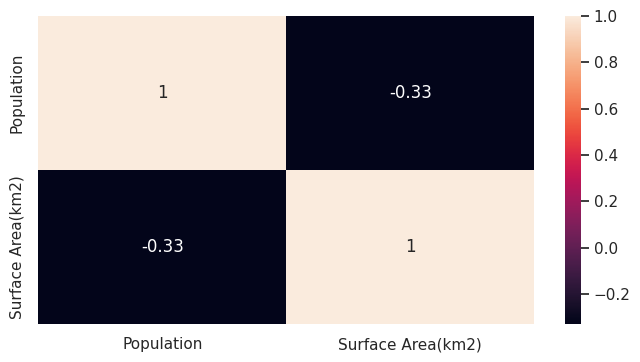

In [ ]:
df_plot = df_exam[['Population','Surface Area(km2)']]
df_plot.corr()

plt.figure(figsize=(8,4))
sns.heatmap(df_plot.corr(), annot=True)

# Distribución P. y Estadística

In [29]:
# 1) Librerías
import math
from statistics import NormalDist

## Distribución Discreta
Una **distribución discreta** describe variables aleatorias que solo pueden tomar **valores contables**.

### I. Distribución Binomial
Número de éxitos en un número fijo de intentos independientes, donde cada intento sólo tiene 2 resultados posibles.

![Distribución Binomial](https://raw.githubusercontent.com/AxisAngeles/Smart_Data_DS_AI/main/dst_binomial.png)'

número de intentos: 100
probabilidad de éxito [0 a 1]: .5


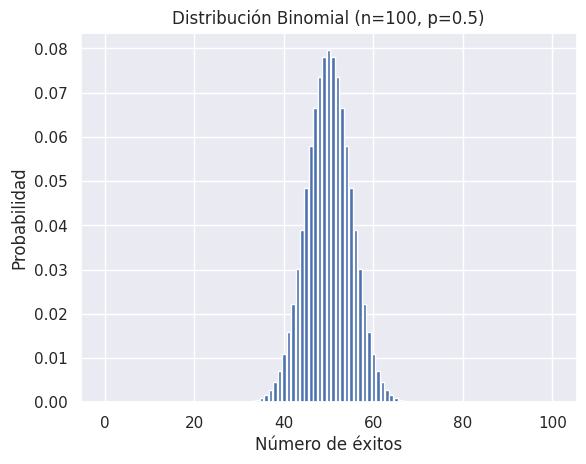

1.0

In [31]:
# 1) Función con la fórmula de Dis. Binomial
# "comb" = "Binomial Coefficient"

def binomial_pmf(k, n, p):
    return math.comb(n, k) * (p**k) * ((1-p)**(n-k))

n = int(input("número de intentos: "))
p = float(input("probabilidad de éxito [0 a 1]: "))

ks = list(range(0, n+1))
probs = [binomial_pmf(k, n, p) for k in ks]

plt.figure()
plt.bar(ks, probs)
plt.title(f"Distribución Binomial (n={n}, p={p})")
plt.xlabel("Número de éxitos")
plt.ylabel("Probabilidad")
plt.show()

sum(probs)

### II. Distribución Poisson
Número de veces que ocurre un evento en un intervalo fijo de tiempo o espacio, cuando:
- Los eventos ocurren de forma aleatoria
- El promedio de ocurrencias es constante

![Distribución Poisson](https://raw.githubusercontent.com/AxisAngeles/Smart_Data_DS_AI/main/dst_poisson.png)'

Tasa promedio de ocurrencia: 3
número de intentos: 50


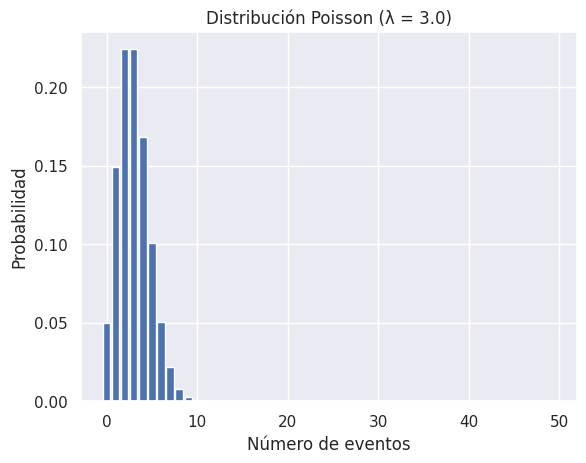

1.0

In [33]:
# 1) Función con la fórmula de Dis. Poisson
# En función de número de eventos (k) y probabilidad de que ocurran "k" eventos

def poisson_pmf(k, lam):
    return math.exp(-lam) * (lam**k) / math.factorial(k)

lam = float(input("Tasa promedio de ocurrencia: "))
n = int(input("número de intentos: "))

ks = list(range(0, n))
probs = [poisson_pmf(k, lam) for k in ks]

plt.figure()
plt.bar(ks, probs)
plt.title(f"Distribución Poisson (λ = {lam})")
plt.xlabel("Número de eventos")
plt.ylabel("Probabilidad")
plt.show()

sum(probs)


## Distribución Continua
Una **distribución continua** describe variables aleatorias que pueden tomar **infinitos valores posibles** dentro de un intervalo.

### I. Distribución Normal

La distribución normal describe variables que:
- Se concentran alrededor de un promedio
- Son simétricas
- Tienen forma de campana

Parámetros:
- **μ (media)**  
- **σ (desviación estándar)**

![Distribución Normal](https://raw.githubusercontent.com/AxisAngeles/Smart_Data_DS_AI/main/dst_normal.png)'

### Regla empírica
- 68% de los valores están dentro de ±1σ  
- 95% dentro de ±2σ  
- 99.7% dentro de ±3σ


Media: 50
Desviación Estándar: 10
Número de muestra: 5000


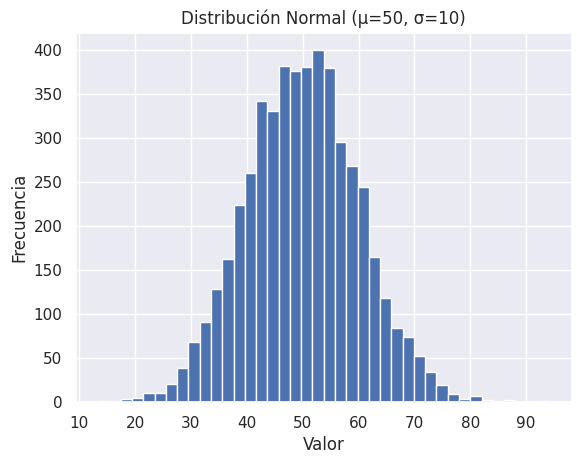

(np.float64(49.968462840399404), np.float64(10.039443813430465))

In [38]:
# 1) Utilizamos la distribución aleatoria (normal) con los parámetros de media y desv. estándar
mu = int(input("Media: "))
sigma = int(input("Desviación Estándar: "))
n = int(input("Número de muestra: "))

x = np.random.normal(mu, sigma, n)

plt.figure()
plt.hist(x, bins=40)
plt.title(f"Distribución Normal (μ={mu}, σ={sigma})")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()

x.mean(), x.std()

### 2.2 Normal Estándar y Z-score

### 📌 Definición teórica
El **Z-score** mide cuántas desviaciones estándar se encuentra un valor respecto al promedio.

Fórmula:
Z = (x − μ) / σ

---
### 📍 Ejemplos reales de uso
1. Detección de **outliers**  
2. Comparar valores en diferentes escalas  
3. Cálculo de probabilidades en la normal

---


In [39]:
mu = int(input("Media: "))
sigma = int(input("Desviación Estándar: "))
x_val = int(input("Valor a normalizar: "))

z = (x_val - mu) / sigma
z

# Probabilidad de observar un valor mayor a x_val
1 - NormalDist().cdf(z)

Media: 50
Desviación Estándar: 10
Valor a normalizar: 65


0.06680720126885809